<a href="https://colab.research.google.com/github/shubham-bari/Reinforcement-Learning/blob/main/Temporal_Difference.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Temporal Difference Prediction Problems for a Random Walk

In [1]:
import random


n_states = 7
alpha = 0.1
gamma = 1.0

# value function initialization
V = [0.0] * n_states
V[6] = 1.0
V[0] = 0.0

def step(state):
    # random policy: left or right
    action = random.choice([-1, 1])
    next_state = state + action

    reward = 1.0 if next_state == 6 else 0.0
    return next_state, reward

episodes = 1000

for _ in range(episodes):
    state = 3  # start from C

    while state not in [0, 6]:
        next_state, reward = step(state)


        V[state] += alpha * (reward + gamma * V[next_state] - V[state])

        state = next_state

print("Estimated values:")
for s in range(1, 6):
    print(f"State {s}: {V[s]:.3f}")


Estimated values:
State 1: 0.306
State 2: 0.824
State 3: 1.245
State 4: 1.510
State 5: 1.771


# CLIFF WALKING PROBLEM DIFFERENCES USING Q-LEARNING AND SARSA

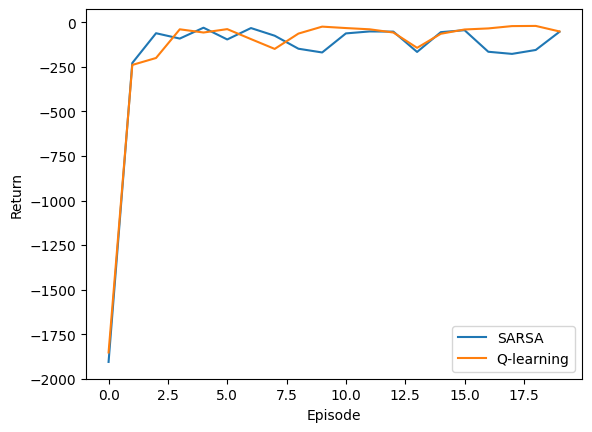

In [6]:
import numpy as np
import random
import matplotlib.pyplot as plt

H, W = 4, 12
S, A = H * W, 4
START, GOAL = (3, 0), (3, 11)
CLIFF = [(3, i) for i in range(1, 11)]

def s_idx(r, c):
    return r * W + c

def step(s, a):
    r, c = divmod(s, W)
    if a == 0: r -= 1
    if a == 1: r += 1
    if a == 2: c -= 1
    if a == 3: c += 1
    r = min(max(r, 0), H - 1)
    c = min(max(c, 0), W - 1)
    if (r, c) in CLIFF:
        return s_idx(*START), -100
    if (r, c) == GOAL:
        return s_idx(r, c), 0
    return s_idx(r, c), -1

def eps_greedy(Q, s, eps):
    if random.random() < eps:
        return random.randrange(A)
    return np.argmax(Q[s])

def sarsa(episodes=20, alpha=0.5, gamma=0.8, eps=0.1):
    Q = np.zeros((S, A))
    rewards = []
    for _ in range(episodes):
        s = s_idx(*START)
        a = eps_greedy(Q, s, eps)
        ep_r = 0
        while s != s_idx(*GOAL):
            s2, r = step(s, a)
            a2 = eps_greedy(Q, s2, eps)
            Q[s, a] += alpha * (r + gamma * Q[s2, a2] - Q[s, a])
            s, a = s2, a2
            ep_r += r
        rewards.append(ep_r)
    return Q, rewards

def q_learning(episodes=20, alpha=0.5, gamma=0.8, eps=0.1):
    Q = np.zeros((S, A))
    rewards = []
    for _ in range(episodes):
        s = s_idx(*START)
        ep_r = 0
        while s != s_idx(*GOAL):
            a = eps_greedy(Q, s, eps)
            s2, r = step(s, a)
            Q[s, a] += alpha * (r + gamma * np.max(Q[s2]) - Q[s, a])
            s = s2
            ep_r += r
        rewards.append(ep_r)
    return Q, rewards

_, r_sarsa = sarsa()
_, r_ql = q_learning()

plt.figure()
plt.plot(r_sarsa, label="SARSA")
plt.plot(r_ql, label="Q-learning")
plt.xlabel("Episode")
plt.ylabel("Return")
plt.legend()
plt.show()
